# AI Final Project 🩵!

📊 The Dataset used in this project is :
"Ames Housing Dataset" . 🏡💲

[link text]()📍 - Import The all required libraries .

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Ames Housing Dataset 🔃


In [62]:
ames_data=pd.read_csv("/content/AmesHousing.csv")

ℹ️ 🔧 Understanding the data .


---

In this step:I explore the dataset to understand its structure + the basic informatipn befor starting , that helps me prepare the next steps.⏮️





In [63]:
print("1️⃣ Data shape :\n",ames_data.shape)
print("\n 2️⃣Data information \n :",ames_data.info())
print("\n 3️⃣ Summary statistics :\n",ames_data.describe())
print("\n 5️⃣ the first 10 row \n ",ames_data.head(10))


1️⃣ Data shape :
 (2930, 82)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null 

 # cleaning plane !🧹


---








#  copy data ©️


---


1️⃣ befor any step i wiil take a copy from the data to avoid errors.



In [64]:
ames_data_copy = ames_data.copy()


#❗Important point


---


2️⃣ : *fix_types Function*


After cheeking the data types I converted two columns , these  columns were converted ti categorical type becausw they represent categories , not real numeric values .

In [65]:
def fix_types(ames_data_copy):
  ames_data_copy["Mo Sold"]=ames_data_copy["Mo Sold"].astype("category")
  ames_data_copy["MS SubClass"] = ames_data_copy["MS SubClass"].astype(str)
  return ames_data_copy


3️⃣ : *check_missing_values Function*

This function shows missing values in all columns ,
My goal is to select the columns that has missing values prepared them to be fixed.  


In [66]:
def check_missing_values(ames_data_copy):
  print(ames_data_copy.isnull().sum().sort_values(ascending=False))
  return ames_data_copy


4️⃣ : *drop_columns Function *

In this function i removed that are not useful for the analysis.

-*Pool QC * : contains 100% missing values.  

- *Misc Feature* : has about 96% missing values.

- *Alley* : has around 93% missing values.

- *Fence* : has about 80% missing values.

✨: since most values in these columns are missing , they provide very little useful information .

❗: the **street** column was also removed because it contains only one value (Pave) with no variation , so it does not add useful information to the analysis.


In [67]:
def drop_columns(ames_data_copy):
  ames_data_copy= ames_data_copy.drop(["Pool QC","Misc Feature","Alley","Fence","Street"],axis=1)
  return ames_data_copy



--
5️⃣ :**imputation_columns_median Function**

 Missing values in numerical were filled using the median because it is more robust to outliers .


In [68]:
def imputation_columns_median(ames_data_copy):
      imputation_columns_madian=["Lot Frontage","Total Bsmt SF","BsmtFin SF 2","BsmtFin SF 1",
"Garage Area","Garage Cars","Bsmt Unf SF"]
      for col in imputation_columns_madian:
        ames_data_copy[col]=ames_data_copy[col].fillna(ames_data_copy[col].median())
      return ames_data_copy

6️⃣ : **imputation_columns_None Function**

Missing value in some categorical columns were filled with "None".

This is because in these columns a missing values usually means that the feature does not exist .


In [69]:
def imputation_columns_None(ames_data_copy):
      imputation_columns_None=["Garage Qual","Garage Finish","Garage Cond","Garage Type","Fireplace Qu","BsmtFin Type 2",
 "Bsmt Qual","Bsmt Cond","BsmtFin Type 1",
 "Bsmt Exposure","Mas Vnr Type"]
      for col in imputation_columns_None:
        ames_data_copy[col]=ames_data_copy[col].fillna("None")
      return ames_data_copy

7️⃣ : **imputation_columns_Zero Function**

This is because a missing value in these columns means that the feature does not exist


In [70]:
def imputation_columns_Zero(ames_data_copy):
    imputation_columns_Zero=["Garage Yr Blt","Bsmt Half Bath","Bsmt Full Bath","Mas Vnr Area"]
    for col in imputation_columns_Zero:
        ames_data_copy[col]=ames_data_copy[col].fillna(0)
    return ames_data_copy


8️⃣ : **imputation_columns_Mode Function**


The missing value in the Electrical column was filled using the mode .

The mode was used because Electrical is a categorical column , and the mode representes the most frequent value in the column



In [71]:
def imputation_columns_Mode(ames_data_copy):
  ames_data_copy["Electrical"]=ames_data_copy["Electrical"].fillna(ames_data_copy["Electrical"].mode()[0])
  return ames_data_copy

9️⃣ : **check_duplicated Function **

This function checks the dataset for duplicated rows and prints their number.


In [72]:
def check_duplicated(ames_data_copy):
  print("Duplicated rows :" ,ames_data_copy.duplicated().sum())
  return ames_data_copy

🔟 : **target_column_outliers Function **

I use a boxplot to visualize outliers in the Saleprice column.

In [73]:
def target_column_outliers(ames_data_copy):
  sns.boxplot(x=ames_data_copy["SalePrice"])
  plt.title("check SalePrice outliers")
  plt.show()
  return ames_data_copy

1️⃣1️⃣ : ** handle_outliers Function**

This function calculates the 99th percentile of the saleprice column and caps values above this threshold to reduce the effect of outliers.
# outliers verification ✂️
## In this step: ❕

 I print the 99th percentile value and the maximum Saleprice after
cleaning to confirm that the outliers were capped correctly .


In [74]:
def handle_outliers(ames_data_copy):
      p99=ames_data_copy["SalePrice"].quantile(0.99)
      print(p99)
      ames_data_copy["SalePrice"]=ames_data_copy["SalePrice"].clip(upper=p99)
      print(p99)
      print(ames_data_copy["SalePrice"].max())
      return ames_data_copy

1️⃣2️⃣ : **boxplot_outliers Function**

This fuction plots a boxplot of the saleprice column after capping to verify that the outliers have been handled.


In [75]:
def boxplot_outliers(ames_data_copy):
  sns.boxplot(x=ames_data_copy["SalePrice"])
  plt.title("SalesPrice After capping")
  plt.show()
  return ames_data_copy





---
🚩🔚 : **Apply cleaning Function**
Finally the clean_data function is applied the dataset to perform all cleaning step .


Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Finish      159
Garage Yr Blt      159
                  ... 
Mo Sold              0
Yr Sold              0
Sale Type            0
Sale Condition       0
SalePrice            0
Length: 77, dtype: int64
Duplicated rows : 0


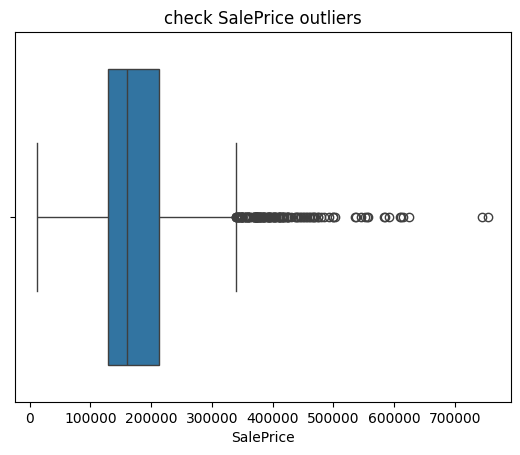

456666.3700000001
456666.3700000001
456666.3700000001


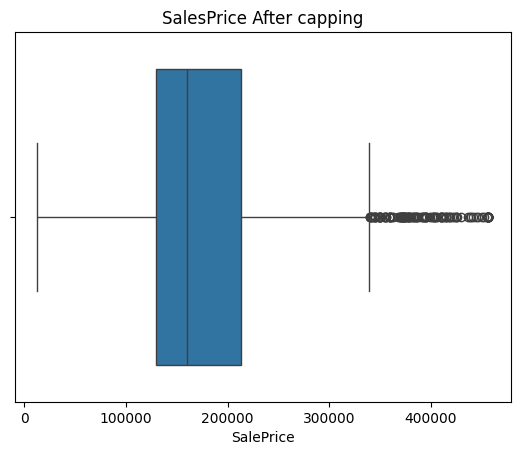

In [76]:
def clean_data(ames_data_copy):
  ames_data_copy = fix_types(ames_data_copy)
  ames_data_copy = drop_columns(ames_data_copy)
  ames_data_copy = check_missing_values(ames_data_copy)
  ames_data_copy = imputation_columns_Zero(ames_data_copy)
  ames_data_copy = imputation_columns_None(ames_data_copy)
  ames_data_copy = imputation_columns_median(ames_data_copy)
  ames_data_copy = imputation_columns_Mode(ames_data_copy)
  ames_data_copy = check_duplicated(ames_data_copy)
  ames_data_copy = target_column_outliers(ames_data_copy)
  ames_data_copy = handle_outliers(ames_data_copy)
  ames_data_copy = boxplot_outliers(ames_data_copy)
  return ames_data_copy
ames_data_copy = clean_data(ames_data_copy)

# Data validation cheeks☑️


---

In this step ⁉:

1- Make sure that the target column has no **missing values ** .

2- Make sure that all values in the target column ** greater than 0 **

3- Make sure that number of columns IS correct after **dropping 5 unnecessary columns**


## Finally 🎉

if all conditions are satisfied , a message will be printed to confirm that all checks passed .



In [77]:
assert ames_data_copy["SalePrice"].isnull().sum()==0
assert(ames_data_copy["SalePrice"]>0).all()
assert ames_data_copy.shape[1] < ames_data.shape[1]
print("All checks passed ☑️🎉")



All checks passed ☑️🎉


# ✨ Data saving .

## in this step i saved the datasey after applying cleaning function .

In [78]:
ames_data_copy.to_csv("clean_ames_data.csv",index=False)
print("Saveing data is complete✨🤍")

Saveing data is complete✨🤍


# The End 🔚


---


## Phase 1 is Done☑️🎉